*  DSC 540
*  Week 1 and 2
*  Anish Samuel

# Activity 3.01: Generating Statistics from a CSV File

In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Boston_housing.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
print("Total number of records : ", df.shape)

Total number of records :  (506, 14)


In [4]:
df_smaller = df.drop(columns=['CHAS','NOX', 'B', 'LSTAT'])
df_smaller.head()

,CRIM,ZN,INDUS,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
0,0.00632,18.0,2.31,6.575,65.2,4.0900,1,296,15.3,24.0
1,0.02731,0.0,7.07,6.421,78.9,4.9671,2,242,17.8,21.6
2,0.02729,0.0,7.07,7.185,61.1,4.9671,2,242,17.8,34.7
3,0.03237,0.0,2.18,6.998,45.8,6.0622,3,222,18.7,33.4
4,0.06905,0.0,2.18,7.147,54.2,6.0622,3,222,18.7,36.2


In [5]:
df_smaller.tail(7)

,CRIM,ZN,INDUS,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
499,0.17783,0.0,9.69,5.569,73.5,2.3999,6,391,19.2,17.5
500,0.22438,0.0,9.69,6.027,79.7,2.4982,6,391,19.2,16.8
501,0.06263,0.0,11.93,6.593,69.1,2.4786,1,273,21.0,22.4
502,0.04527,0.0,11.93,6.120,76.7,2.2875,1,273,21.0,20.6
503,0.06076,0.0,11.93,6.976,91.0,2.1675,1,273,21.0,23.9
504,0.10959,0.0,11.93,6.794,89.3,2.3889,1,273,21.0,22.0
505,0.04741,0.0,11.93,6.030,80.8,2.5050,1,273,21.0,11.9


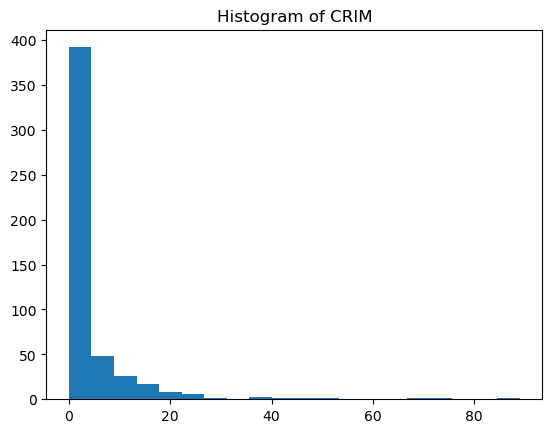

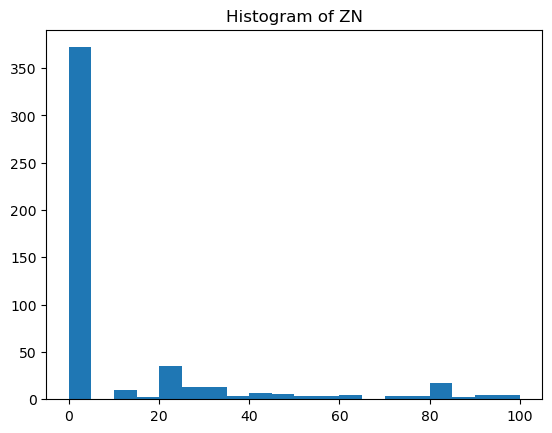

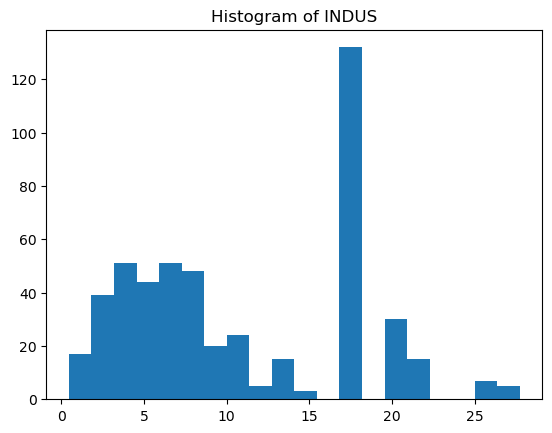

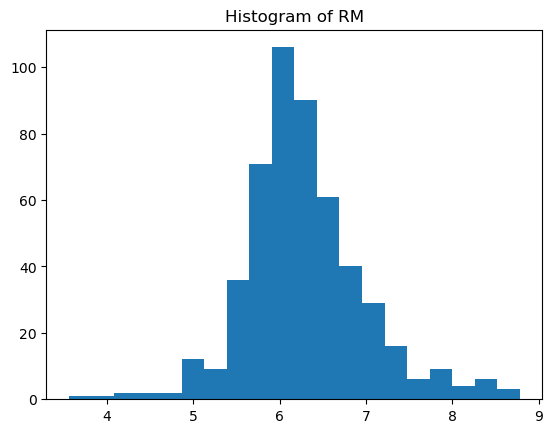

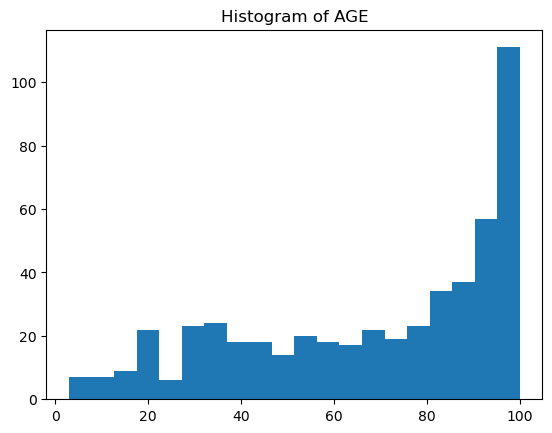

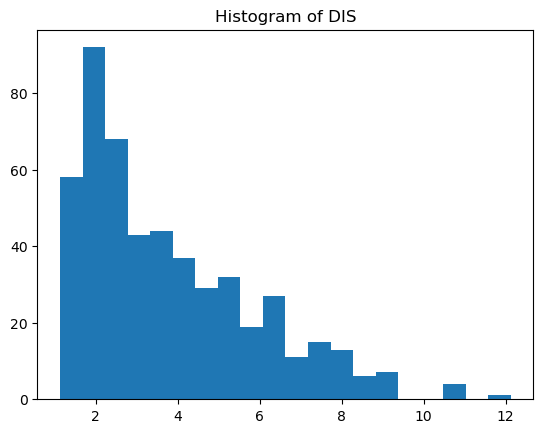

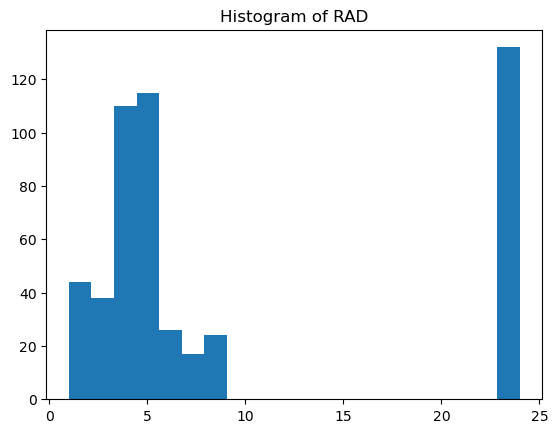

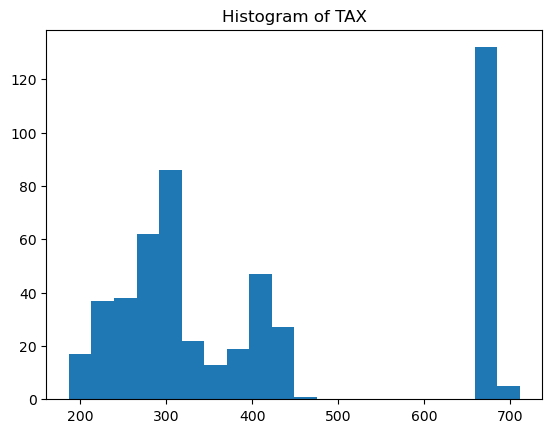

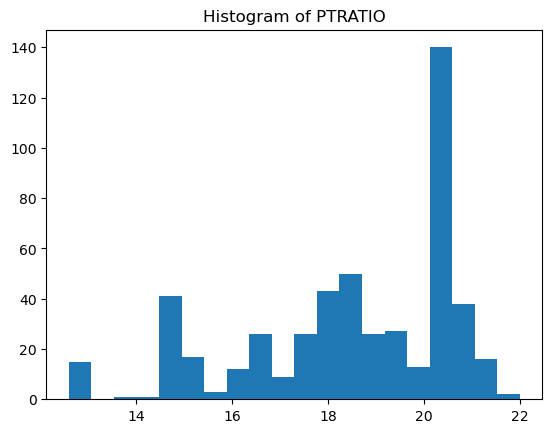

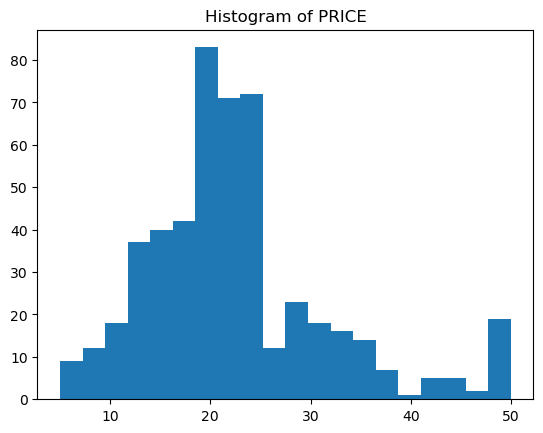

In [6]:
for col in df_smaller.columns:
    plt.title("Histogram of "+col)
    plt.hist(df_smaller[col], bins=20)
    plt.show()

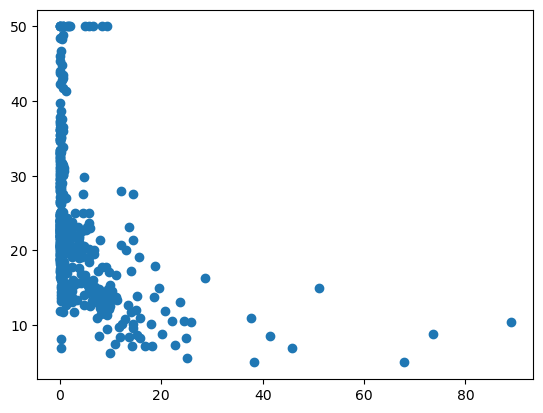

In [7]:
plt.scatter(df_smaller['CRIM'], df_smaller['PRICE'])
plt.show()

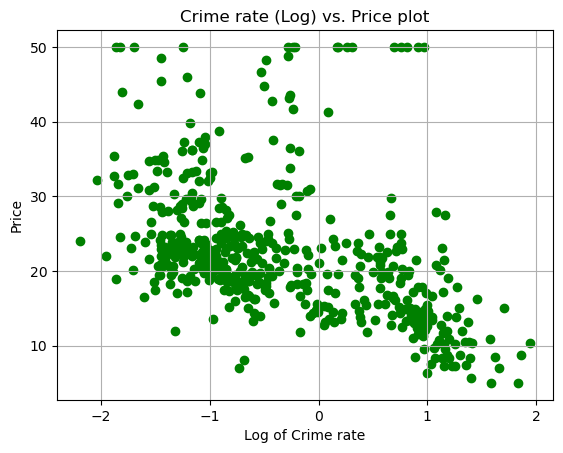

In [8]:
plt.scatter(np.log10(df_smaller['CRIM']), df_smaller['PRICE'], c='green')
plt.title("Crime rate (Log) vs. Price plot")
plt.xlabel("Log of Crime rate")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [9]:
print("MEAN: ",df_smaller['RM'].mean())

MEAN:  6.284634387351779


In [10]:
print("MEDIAN: ",df_smaller['AGE'].median())

MEDIAN:  77.5


In [11]:
print("AVERAGE/MEAN: ",df_smaller['DIS'].mean())

AVERAGE/MEAN:  3.795042687747036


In [12]:
low_price = df_smaller['PRICE'] < 20
print("Price of the housing that's less than 20: ", low_price)

Price of the housing that's less than 20:  0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505     True
Name: PRICE, Length: 506, dtype: bool


In [13]:
print("MEAN OF LOW PRICE: ", low_price.mean())

MEAN OF LOW PRICE:  0.4150197628458498


In [14]:
print("Percentage of houses with a low price (< $20,000): ", low_price.mean()*100)

Percentage of houses with a low price (< $20,000):  41.50197628458498


# Activity 4.01: Working with the Adult Income Dataset (UCI)

In [15]:
df_income = pd.read_csv("adult_income_data.csv")
df_income.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,Female,0,0,40,United-States,<=50K


In [16]:
names = []
with open("adult_income_names.txt", 'r') as f:
    for line in f:
        f.readline()
        names.append(line.split(":")[0])

names

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country']

In [17]:
if('Income' not in names):
    names.append("Income")
names

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'Income']

In [18]:
df_income = pd.read_csv("adult_income_data.csv", names=names)
df_income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K


In [19]:
df_income.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [20]:
df_income.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
Income            0
dtype: int64

In [21]:
df_income_subset = df_income[['age', 'education', 'occupation']]
df_income_subset .head()

,age,education,occupation
0,39,Bachelors,Adm-clerical
1,50,Bachelors,Exec-managerial
2,38,HS-grad,Handlers-cleaners
3,53,11th,Handlers-cleaners
4,28,Bachelors,Prof-specialty


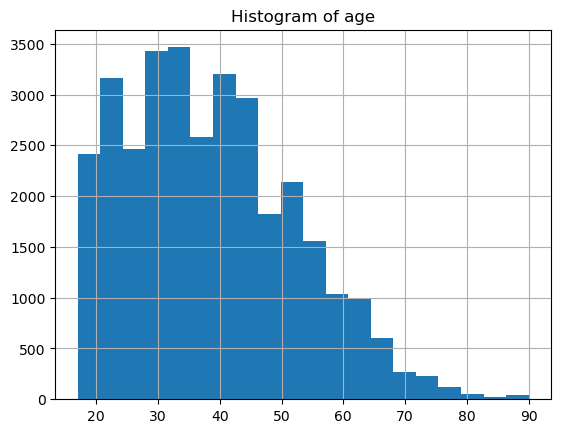

In [22]:
plt.title("Histogram of age")
plt.hist(df_income_subset['age'], bins=20)
plt.grid()
plt.show()

In [23]:
def strip_whitespaces(s):
    return s.strip()

str_cols = df_income.select_dtypes(include=['object']).columns
for col in str_cols:
    new_col = col + '_stripped'
    df_income[new_col] = df_income[col].apply(strip_whitespaces)
    df_income[col] = df_income[new_col]
    df_income.drop(columns=[new_col], inplace=True)

df_income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K


In [ ]:
df_income_filtered = df_income_subset[(df_income_subset['age'] >= 30) & (df_income_subset['age']<=50)]
df_income_filtered.head()

,age,education,occupation
0,39,Bachelors,Adm-clerical
1,50,Bachelors,Exec-managerial
2,38,HS-grad,Handlers-cleaners
3,53,11th,Handlers-cleaners
4,28,Bachelors,Prof-specialty


In [25]:
occupation_stats=df_income_subset.groupby('occupation').describe()['age']
occupation_stats

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
?,1843.0,40.882800,20.336350,17.0,21.0,35.0,61.0,90.0
Adm-clerical,3770.0,36.964456,13.362998,17.0,26.0,35.0,46.0,90.0
Armed-Forces,9.0,30.222222,8.089774,23.0,24.0,29.0,34.0,46.0
Craft-repair,4099.0,39.031471,11.606436,17.0,30.0,38.0,47.0,90.0
Exec-managerial,4066.0,42.169208,11.974548,17.0,33.0,41.0,50.0,90.0
Farming-fishing,994.0,41.211268,15.070283,17.0,29.0,39.0,52.0,90.0
Handlers-cleaners,1370.0,32.165693,12.372635,17.0,23.0,29.0,39.0,90.0
Machine-op-inspct,2002.0,37.715285,12.068266,17.0,28.0,36.0,46.0,90.0
Other-service,3295.0,34.949621,14.521508,17.0,22.0,32.0,45.0,90.0


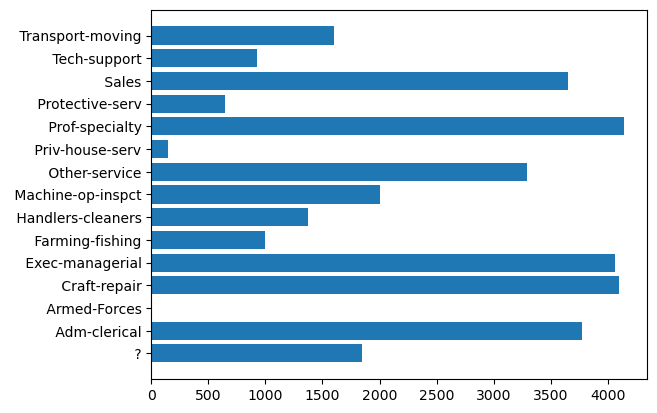

In [26]:
plt.barh(y=occupation_stats.index, width=occupation_stats['count'])
plt.yticks()
plt.show()

In [27]:
df_1 = df_income[['age','workclass','occupation']].sample(5,random_state=101)
df_1.head()

,age,workclass,occupation
22357,51,Private,Machine-op-inspct
26009,19,Private,Sales
20734,40,Private,Exec-managerial
17695,17,Private,Handlers-cleaners
27908,61,Private,Craft-repair


In [28]:
df_2 = df_income[['education','occupation']].sample(5,random_state=101)
df_2.head()

,education,occupation
22357,HS-grad,Machine-op-inspct
26009,11th,Sales
20734,HS-grad,Exec-managerial
17695,10th,Handlers-cleaners
27908,7th-8th,Craft-repair


In [29]:
df_merged = pd.merge(df_1,df_2, on='occupation', how='inner').drop_duplicates()
df_merged

,age,workclass,occupation,education
0,51,Private,Machine-op-inspct,HS-grad
1,19,Private,Sales,11th
2,40,Private,Exec-managerial,HS-grad
3,17,Private,Handlers-cleaners,10th
4,61,Private,Craft-repair,7th-8th


# 3. Create a series and practice basic arithmetic steps

In [30]:
series1 = pd.Series([7.3, -2.5, 3.4, 1.5], index=['a', 'c', 'd', 'e'])
series2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1], index=['a', 'c', 'e', 'f', 'g'])

series_add = series1 + series2
print("Added series : \n", series_add)

Added series : 
 a    5.2
c    1.1
d    NaN
e    0.0
f    NaN
g    NaN
dtype: float64


In [31]:
series_substract = series1 - series2
print("Substracted series : \n", series_substract)

Substracted series : 
 a    9.4
c   -6.1
d    NaN
e    3.0
f    NaN
g    NaN
dtype: float64
